# RAG Evaluation Notebook

Notebook danh gia retrieval cho he thong RAG theo huong nghien cuu khoa hoc.

Chi so: Recall@K, Precision@K, HitRate@K, MRR@K, nDCG@K va latency statistics.

## 1) Cai dat thu vien
Neu chua co, chay cell ben duoi de cai dat dependencies.

In [1]:
# %pip install requests pandas matplotlib

## 2) Cau hinh thuc nghiem

In [2]:
from pathlib import Path
from datetime import datetime
import json
import math
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "http://localhost:8000"
ENDPOINT = "/api/v1/search"
DATASET_PATH = Path("../dataset/ground_truth.v1.json")
OUTPUT_ROOT = Path("../output")
KS = [1, 3, 5, 10]
TIMEOUT_SEC = 15

assert DATASET_PATH.exists(), f"Khong tim thay dataset: {DATASET_PATH.resolve()}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

run_id = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
out_dir = OUTPUT_ROOT / run_id
charts_dir = out_dir / "charts"
out_dir.mkdir(parents=True, exist_ok=True)
charts_dir.mkdir(parents=True, exist_ok=True)

print("Output dir:", out_dir.resolve())

Output dir: /Users/phuc/Coding/Git/admission-rag-chatbot/evaluation-rag/output/2026-05-08T17-30-36


## 3) Ham tinh metric

In [3]:
def dcg_at_k(rel, k):
    s = 0.0
    for i, r in enumerate(rel[:k]):
        s += r / math.log2(i + 2)
    return s

def metrics_for_query(retrieved_ids, relevant_set, ks):
    total_rel = len(relevant_set)
    out = {}
    for k in ks:
        top = retrieved_ids[:k]
        tp = 0
        first_rank = None
        rel_vec = []

        for i, cid in enumerate(top, start=1):
            is_rel = cid in relevant_set
            rel_vec.append(1 if is_rel else 0)
            if is_rel:
                tp += 1
                if first_rank is None:
                    first_rank = i

        precision = tp / k if k > 0 else 0.0
        recall = tp / total_rel if total_rel > 0 else 0.0
        hit_rate = 1.0 if tp > 0 else 0.0
        mrr = 1.0 / first_rank if first_rank else 0.0

        idcg_vec = [1] * min(total_rel, k)
        ndcg = (dcg_at_k(rel_vec, k) / dcg_at_k(idcg_vec, k)) if idcg_vec else 0.0

        out[f"precision@{k}"] = precision
        out[f"recall@{k}"] = recall
        out[f"hit_rate@{k}"] = hit_rate
        out[f"mrr@{k}"] = mrr
        out[f"ndcg@{k}"] = ndcg
    return out

## 4) Chay benchmark truy van

In [4]:
dataset = json.loads(DATASET_PATH.read_text(encoding="utf-8"))
assert isinstance(dataset, list) and len(dataset) > 0

url = BASE_URL.rstrip("/") + ENDPOINT
raw_rows = []

for item in dataset:
    query_id = str(item.get("id", ""))
    query = str(item.get("query", ""))
    uni = item.get("university_code")
    rel_ids = [str(x) for x in item.get("relevant_chunk_ids", [])]

    payload = {"query": query}
    if uni:
        payload["university_code"] = str(uni)

    t0 = time.perf_counter()
    status = "ok"
    error = ""
    hits = []

    try:
        resp = requests.post(url, json=payload, timeout=TIMEOUT_SEC)
        resp.raise_for_status()
        body = resp.json()
        hits = body.get("hits", []) if isinstance(body, dict) else []
    except Exception as ex:
        status = "error"
        error = str(ex)

    latency_ms = (time.perf_counter() - t0) * 1000

    raw_rows.append({
        "id": query_id,
        "query": query,
        "university_code": str(uni or ""),
        "relevant_chunk_ids": rel_ids,
        "retrieved_chunk_ids": [str(h.get("chunk_id") or h.get("id") or "") for h in hits],
        "scores": [float(h.get("score") or 0.0) for h in hits],
        "latency_ms": latency_ms,
        "status": status,
        "error": error,
    })

len(raw_rows), sum(1 for r in raw_rows if r['status'] == 'ok')

(72, 0)

## 5) Tinh toan metric va tao bang

In [5]:
per_query = []
for r in raw_rows:
    rel_set = set(r['relevant_chunk_ids'])
    m = metrics_for_query(r['retrieved_chunk_ids'], rel_set, KS)
    row = {
        'id': r['id'],
        'query': r['query'],
        'university_code': r['university_code'],
        'status': r['status'],
        'latency_ms': r['latency_ms'],
        'relevant_count': len(rel_set),
        'retrieved_count': len(r['retrieved_chunk_ids']),
        'error': r['error'],
    }
    row.update(m)
    per_query.append(row)

df_per_query = pd.DataFrame(per_query)
df_per_query.head()

,id,query,university_code,status,latency_ms,relevant_count,retrieved_count,error,precision@1,recall@1,...,precision@5,recall@5,hit_rate@5,mrr@5,ndcg@5,precision@10,recall@10,hit_rate@10,mrr@10,ndcg@10
0,IUH_001,điểm chuẩn ngành công nghệ thông tin IUH năm 2025,IUH,error,25.479185,0,0,"HTTPConnectionPool(host='localhost', port=8000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IUH_002,học phí ngành kỹ thuật phần mềm IUH,IUH,error,5.492039,0,0,"HTTPConnectionPool(host='localhost', port=8000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IUH_003,phương thức xét tuyển học bạ của IUH,IUH,error,4.714905,0,0,"HTTPConnectionPool(host='localhost', port=8000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IUH_004,tổ hợp xét tuyển ngành logistics IUH,IUH,error,4.317253,0,0,"HTTPConnectionPool(host='localhost', port=8000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IUH_005,chỉ tiêu tuyển sinh của IUH năm 2025,IUH,error,4.773995,0,0,"HTTPConnectionPool(host='localhost', port=8000...",0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
ok_df = df_per_query[df_per_query['status'] == 'ok']
metric_cols = [c for c in df_per_query.columns if any(c.startswith(p) for p in ['recall@', 'precision@', 'hit_rate@', 'mrr@', 'ndcg@'])]
summary = {c: float(ok_df[c].mean()) if len(ok_df) else 0.0 for c in metric_cols}

lat_stats = {
    'latency_mean_ms': float(df_per_query['latency_ms'].mean()) if len(df_per_query) else 0.0,
    'latency_p50_ms': float(df_per_query['latency_ms'].quantile(0.50)) if len(df_per_query) else 0.0,
    'latency_p95_ms': float(df_per_query['latency_ms'].quantile(0.95)) if len(df_per_query) else 0.0,
    'latency_p99_ms': float(df_per_query['latency_ms'].quantile(0.99)) if len(df_per_query) else 0.0,
}

summary.update({
    'query_count_total': int(len(df_per_query)),
    'query_count_ok': int((df_per_query['status'] == 'ok').sum()),
    'query_count_error': int((df_per_query['status'] == 'error').sum()),
})
summary.update(lat_stats)

df_summary = pd.DataFrame([{'metric': k, 'value': v} for k, v in summary.items()]).sort_values('metric')
df_summary

,metric,value
2,hit_rate@1,0.000000
17,hit_rate@10,0.000000
7,hit_rate@3,0.000000
12,hit_rate@5,0.000000
23,latency_mean_ms,5.908066
24,latency_p50_ms,5.465550
25,latency_p95_ms,8.115387
26,latency_p99_ms,14.066355
3,mrr@1,0.000000
18,mrr@10,0.000000


## 6) Ve bieu do

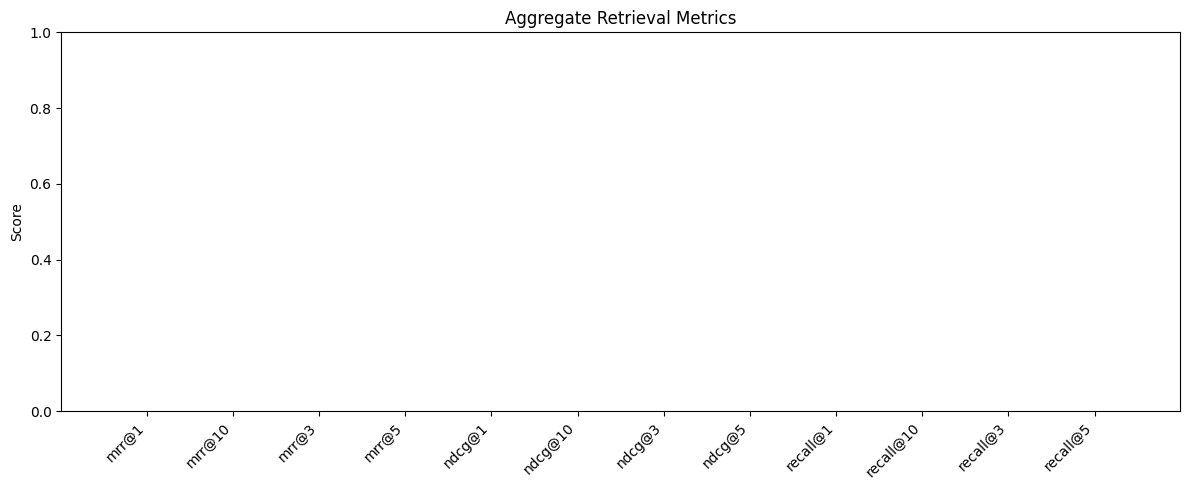

In [7]:
plot_metrics = {k: v for k, v in summary.items() if k.startswith('recall@') or k.startswith('mrr@') or k.startswith('ndcg@')}
plot_metrics = dict(sorted(plot_metrics.items(), key=lambda x: x[0]))

plt.figure(figsize=(12, 5))
plt.bar(plot_metrics.keys(), plot_metrics.values())
plt.title('Aggregate Retrieval Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(charts_dir / 'aggregate_metrics.png', dpi=150)
plt.show()

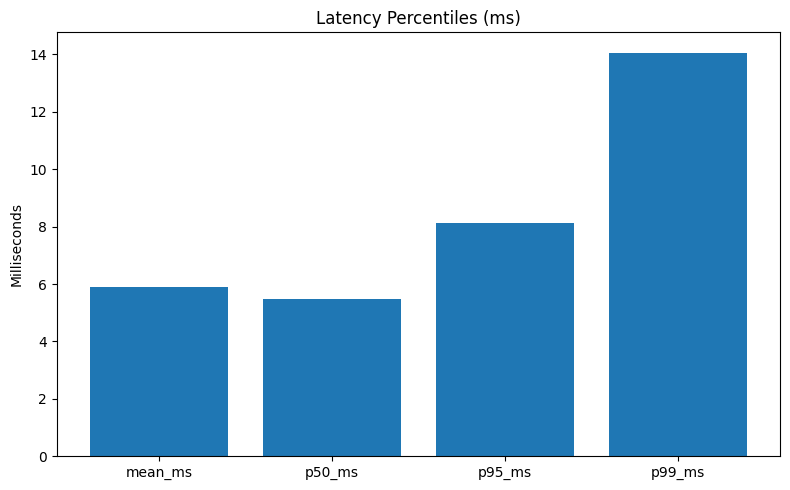

In [8]:
lat = {
    'mean_ms': lat_stats['latency_mean_ms'],
    'p50_ms': lat_stats['latency_p50_ms'],
    'p95_ms': lat_stats['latency_p95_ms'],
    'p99_ms': lat_stats['latency_p99_ms'],
}

plt.figure(figsize=(8, 5))
plt.bar(lat.keys(), lat.values())
plt.title('Latency Percentiles (ms)')
plt.ylabel('Milliseconds')
plt.tight_layout()
plt.savefig(charts_dir / 'latency_percentiles.png', dpi=150)
plt.show()

## 7) Xuat artifact phuc vu bao cao

In [9]:
config = {
    'base_url': BASE_URL,
    'endpoint': ENDPOINT,
    'dataset_path': str(DATASET_PATH),
    'ks': KS,
    'timeout_sec': TIMEOUT_SEC,
    'executed_at': datetime.now().isoformat(),
}

(out_dir / 'config.json').write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding='utf-8')
(out_dir / 'raw_results.json').write_text(json.dumps(raw_rows, indent=2, ensure_ascii=False), encoding='utf-8')
df_per_query.to_csv(out_dir / 'per_query_metrics.csv', index=False)
df_summary.to_csv(out_dir / 'summary_metrics.csv', index=False)

report_lines = [
    '# RAG Evaluation Report',
    '',
    '## Experiment Setup',
    f'- Base URL: {BASE_URL}',
    f'- Endpoint: {ENDPOINT}',
    f'- Dataset: {DATASET_PATH}',
    f'- Query count: {len(df_per_query)}',
    f'- Success count: {int((df_per_query["status"] == "ok").sum())}',
    f'- Error count: {int((df_per_query["status"] == "error").sum())}',
    '',
    '## Retrieval Summary',
]

for k in KS:
    report_lines.append(f'- Recall@{k}: {summary.get(f"recall@{k}", 0.0):.4f}')
    report_lines.append(f'- Precision@{k}: {summary.get(f"precision@{k}", 0.0):.4f}')
    report_lines.append(f'- HitRate@{k}: {summary.get(f"hit_rate@{k}", 0.0):.4f}')
    report_lines.append(f'- MRR@{k}: {summary.get(f"mrr@{k}", 0.0):.4f}')
    report_lines.append(f'- nDCG@{k}: {summary.get(f"ndcg@{k}", 0.0):.4f}')

report_lines.extend([
    '',
    '## Latency Statistics',
    f'- Mean (ms): {lat_stats["latency_mean_ms"]:.2f}',
    f'- P50 (ms): {lat_stats["latency_p50_ms"]:.2f}',
    f'- P95 (ms): {lat_stats["latency_p95_ms"]:.2f}',
    f'- P99 (ms): {lat_stats["latency_p99_ms"]:.2f}',
    '',
    '## Artifacts',
    '- per_query_metrics.csv',
    '- summary_metrics.csv',
    '- raw_results.json',
    '- charts/aggregate_metrics.png',
    '- charts/latency_percentiles.png',
])

(out_dir / 'report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('Da xuat artifact vao:', out_dir.resolve())

Da xuat artifact vao: /Users/phuc/Coding/Git/admission-rag-chatbot/evaluation-rag/output/2026-05-08T17-30-36
